<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
Mini Project | Case Study: Machine Learning Regression, Week 27
</div>


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
Step 1: import the necessary libraries
</div>

In [14]:

import sys
#sys.stdout = open(1, 'w', encoding='utf-8', buffering=1)
import joblib
# Data handling and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, BaggingRegressor, AdaBoostRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
Step 2: load the dataset
</div>

In [15]:
# load excel file
df = pd.read_excel('../data/regression_data.xls', engine='xlrd')
df.head()
df.head()

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
0,7129300520,2014-10-13,3,1.00,1180,5650,1.0,0,0,3,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,221900
1,6414100192,2014-12-09,3,2.25,2570,7242,2.0,0,0,3,...,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,538000
2,5631500400,2015-02-25,2,1.00,770,10000,1.0,0,0,3,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,180000
3,2487200875,2014-12-09,4,3.00,1960,5000,1.0,0,0,5,...,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,604000
4,1954400510,2015-02-18,3,2.00,1680,8080,1.0,0,0,3,...,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,510000


,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
0,7129300520,2014-10-13,3,1.00,1180,5650,1.0,0,0,3,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,221900
1,6414100192,2014-12-09,3,2.25,2570,7242,2.0,0,0,3,...,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,538000
2,5631500400,2015-02-25,2,1.00,770,10000,1.0,0,0,3,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,180000
3,2487200875,2014-12-09,4,3.00,1960,5000,1.0,0,0,5,...,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,604000
4,1954400510,2015-02-18,3,2.00,1680,8080,1.0,0,0,3,...,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,510000


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
Step 3: Data Preprocessing
</div>

In [16]:
# Drop the ID column that are not useful
df = df.drop('id', axis=1)  # ID is irrelevant

In [17]:
# check date column to see how many unique dates there are in each month and year
print(df['date'].dt.year.value_counts())
print(df['date'].dt.month.value_counts())


date
2014    14622
2015     6975
Name: count, dtype: int64
date
5     2414
4     2229
7     2211
6     2178
8     1939
10    1876
3     1875
9     1771
12    1470
11    1409
2     1247
1      978
Name: count, dtype: int64


In [18]:
# changing the date column to ordinal using toordinal() 
df['date'] = pd.to_datetime(df['date']).apply(lambda x: x.toordinal())
df.head()

,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
0,735519,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,221900
1,735576,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,538000
2,735654,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,180000
3,735576,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,604000
4,735647,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,510000


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
Step 3-2: check for missing values
</div>

In [19]:
df.isna().sum()

date             0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
price            0
dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           21597 non-null  int64  
 1   bedrooms       21597 non-null  int64  
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  int64  
 4   sqft_lot       21597 non-null  int64  
 5   floors         21597 non-null  float64
 6   waterfront     21597 non-null  int64  
 7   view           21597 non-null  int64  
 8   condition      21597 non-null  int64  
 9   grade          21597 non-null  int64  
 10  sqft_above     21597 non-null  int64  
 11  sqft_basement  21597 non-null  int64  
 12  yr_built       21597 non-null  int64  
 13  yr_renovated   21597 non-null  int64  
 14  zipcode        21597 non-null  int64  
 15  lat            21597 non-null  float64
 16  long           21597 non-null  float64
 17  sqft_living15  21597 non-null  int64  
 18  sqft_l

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
Step 3-3: check duplicates
</div>

In [21]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [22]:
# Summary statistics
print(df.describe())

                date      bedrooms     bathrooms   sqft_living      sqft_lot  \
count   21597.000000  21597.000000  21597.000000  21597.000000  2.159700e+04   
mean   735535.180997      3.373200      2.115826   2080.321850  1.509941e+04   
std       113.059987      0.926299      0.768984    918.106125  4.141264e+04   
min    735355.000000      1.000000      0.500000    370.000000  5.200000e+02   
25%    735436.000000      3.000000      1.750000   1430.000000  5.040000e+03   
50%    735522.000000      3.000000      2.250000   1910.000000  7.618000e+03   
75%    735646.000000      4.000000      2.500000   2550.000000  1.068500e+04   
max    735745.000000     33.000000      8.000000  13540.000000  1.651359e+06   

             floors    waterfront          view     condition         grade  \
count  21597.000000  21597.000000  21597.000000  21597.000000  21597.000000   
mean       1.494096      0.007547      0.234292      3.409825      7.657915   
std        0.539683      0.086549      0.7

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
Step 4: Exploratory Data Analysis (EDA)
</div>

<Figure size 1200x720 with 0 Axes>

<Axes: xlabel='price', ylabel='Count'>

Text(0.5, 0, 'Price (million USD, log scale)')

Text(0, 0.5, 'Number of houses')

Text(0.5, 1.0, 'Distribution of House Prices (n = 21597)')

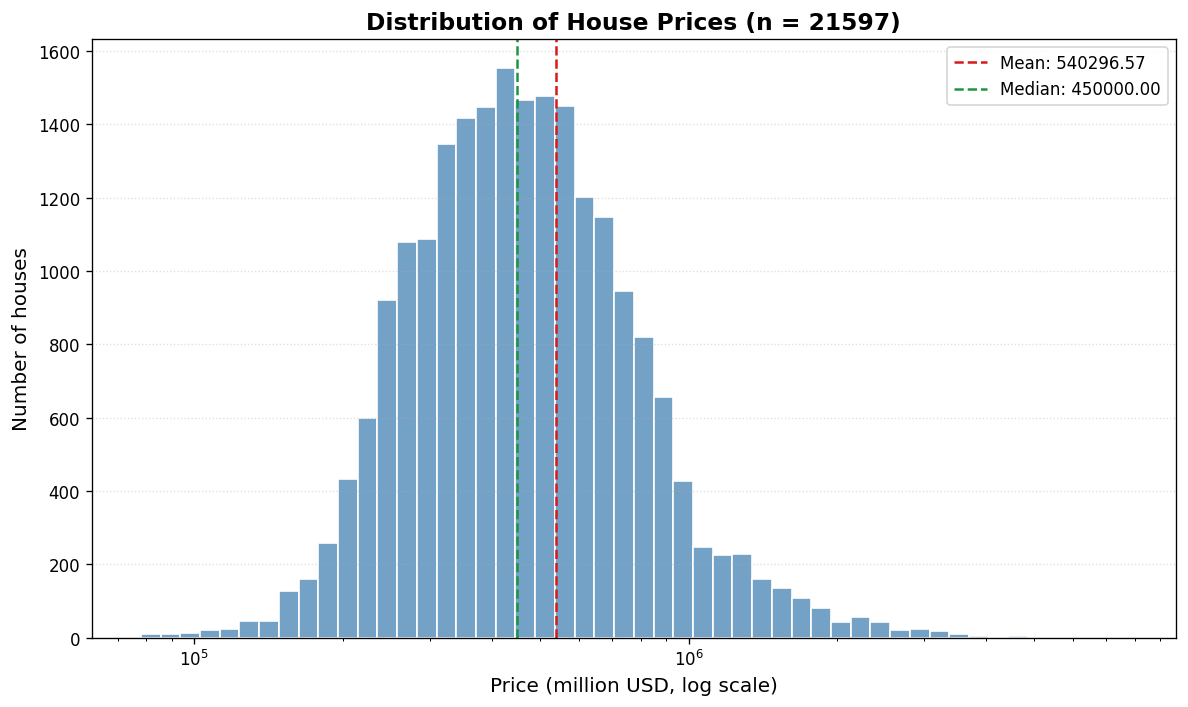

In [23]:
plt.figure(figsize=(10,6), dpi=120)
sns.histplot(df['price'], bins=50, kde=False, 
             color='steelblue', edgecolor='white', log_scale=(True, False))

mean_price = df['price'].mean()
median_price = df['price'].median()
plt.axvline(mean_price, color='#d7191c', linestyle='--', linewidth=1.5, 
            label=f'Mean: {mean_price:.2f}')
plt.axvline(median_price, color='#1a9641', linestyle='--', linewidth=1.5,
            label=f'Median: {median_price:.2f}')

plt.xlabel('Price (million USD, log scale)', fontsize=12)
plt.ylabel('Number of houses', fontsize=12)
plt.title('Distribution of House Prices (n = {})'.format(len(df)), 
          fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1600x1600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation matrix of features and target')

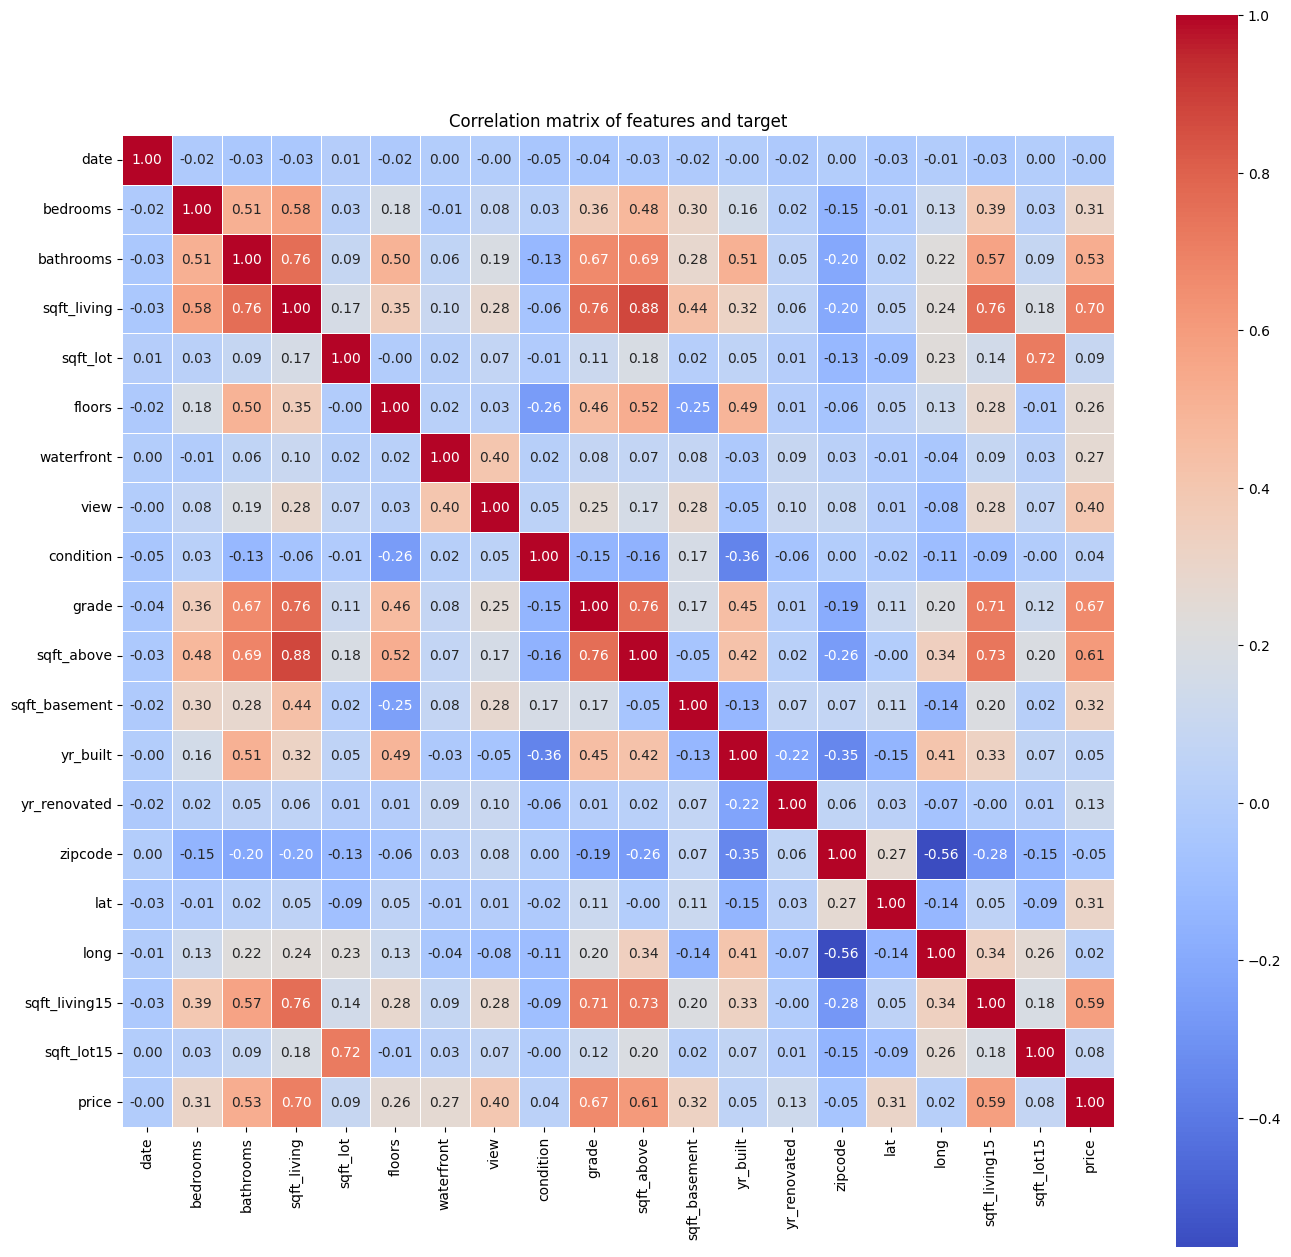

In [24]:
# Correlation heatmap
plt.figure(figsize=(16, 16))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, 
            linewidths=0.5)
plt.title('Correlation matrix of features and target')
plt.show()


In [25]:
# Top features correlated with price
corr_price = corr['price'].sort_values(ascending=False)
print("Correlation with price:\n", corr_price)

Correlation with price:
 price            1.000000
sqft_living      0.701917
grade            0.667951
sqft_above       0.605368
sqft_living15    0.585241
bathrooms        0.525906
view             0.397370
sqft_basement    0.323799
bedrooms         0.308787
lat              0.306692
waterfront       0.266398
floors           0.256804
yr_renovated     0.126424
sqft_lot         0.089876
sqft_lot15       0.082845
yr_built         0.053953
condition        0.036056
long             0.022036
date            -0.003998
zipcode         -0.053402
Name: price, dtype: float64


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
Step 4-2: Checking the impact of time on the price (due to the inflation)
</div>

<Figure size 1200x500 with 0 Axes>

<Axes: xlabel='date_dt'>

Text(0.5, 1.0, 'Average House Price by Month (May 2014 – May 2015)')

Text(0.5, 0, 'Month')

Text(0, 0.5, 'Average Price (USD)')

(array([540]), [Text(540, 0, 'Jan\n2015')])

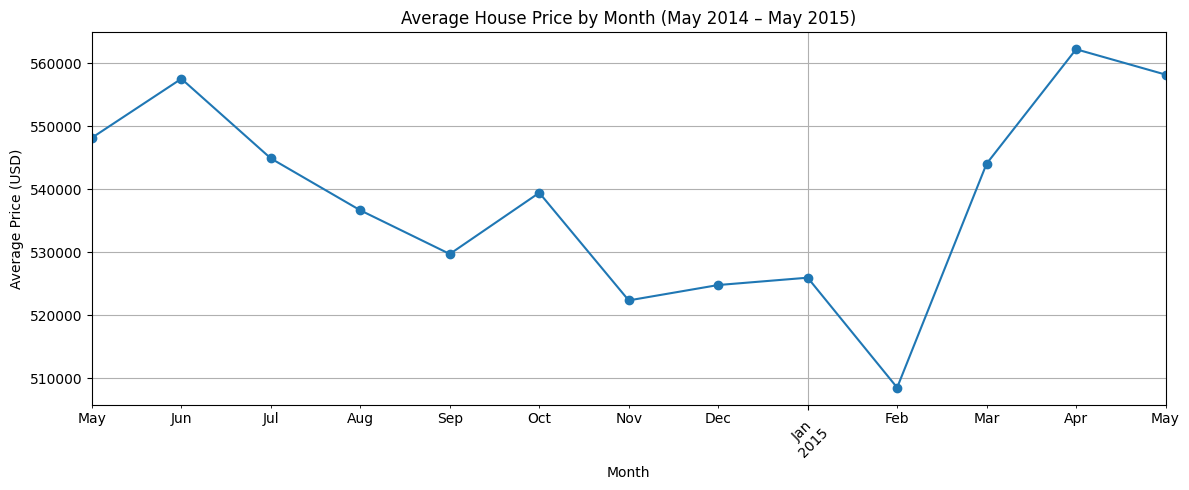

In [27]:
# Price trend over time

# Re‑load the original date (keep a copy before converting to ordinal)
df_original = pd.read_excel('../data/regression_data.xls', engine='xlrd')
df['original_date'] = pd.to_datetime(df_original['date'])

# Using the original date column for time analysis
df_time = df.copy()
df_time['date_dt'] = df_time['original_date']

# Monthly average price
monthly_price = df_time.groupby(df_time['date_dt'].dt.to_period('M'))['price'].mean()

plt.figure(figsize=(12,5))
monthly_price.plot(marker='o', linestyle='-')
plt.title('Average House Price by Month (May 2014 – May 2015)')
plt.xlabel('Month')
plt.ylabel('Average Price (USD)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='month', ylabel='price'>

Text(0.5, 1.0, 'Price Distribution by Month')

Text(0.5, 0, 'Month')

Text(0, 0.5, 'Price')

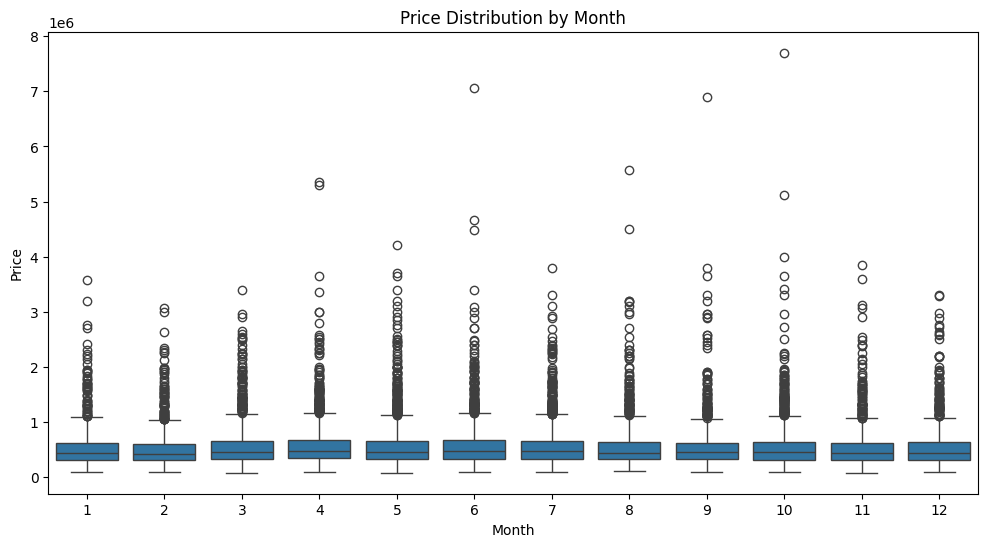

In [28]:
df_time['month'] = df_time['date_dt'].dt.month
plt.figure(figsize=(12,6))
sns.boxplot(x='month', y='price', data=df_time)
plt.title('Price Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Price')
plt.show()

In [29]:

X_date = df[['date']]
y_price = df['price']
lr_date = LinearRegression().fit(X_date, y_price)
print(f"R² of date alone: {lr_date.score(X_date, y_price):.6f}")
print(f"Coefficient: {lr_date.coef_[0]:.2f} (price change per day)")

R² of date alone: 0.000016
Coefficient: -12.99 (price change per day)


In [30]:
# Add month, year, day of week, quarter from the original date
df['month'] = df['original_date'].dt.month
df['year'] = df['original_date'].dt.year
df['day_of_week'] = df['original_date'].dt.dayofweek
df['quarter'] = df['original_date'].dt.quarter


# Use these new features plus all others except 'original_date' and 'price'
X2 = df.drop(['price', 'date', 'original_date'], axis=1)
y2 = df['price']

# Re‑split and scale
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=42)
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

# Train best model (Gradient Boosting)
gb2 = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gb2.fit(X2_train_scaled, y2_train)
y2_pred = gb2.predict(X2_test_scaled)
rmse2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
r22 = r2_score(y2_test, y2_pred)
print(f"With date features: RMSE = {rmse2:.2f}, R² = {r22:.4f}")

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

With date features: RMSE = 128518.37, R² = 0.8796


In [31]:
# Drop the original_date column 
df = df.drop('original_date', axis=1)

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
Step 5: Feature and target split
</div>

In [32]:
# Split features and Target

# Features
X = df.drop(['price'], axis=1)

# Target
y = df["price"]


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
Step 6: split the dataset into training and testing sets
</div>

In [33]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Training size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Training size: 16197, Test size: 5400


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
Step 7: Feature scaling (StandardScaler)
</div>

In [34]:
# Normalisation (Standardisation)

# Create a scaler object
scaler = StandardScaler()

# Fit on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Mean of each feature after scaling (should be ~0):")
print(X_train_scaled.mean())
print("\nStandard deviation after scaling (should be ~1):")
print(X_train_scaled.std())

Mean of each feature after scaling (should be ~0):
date             3.000763e-13
bedrooms         1.083559e-16
bathrooms       -2.588258e-17
sqft_living      1.513473e-17
sqft_lot         2.105702e-17
floors           1.000208e-16
waterfront       2.632127e-17
view             1.754751e-18
condition        2.053059e-16
grade            1.969709e-16
sqft_above       2.829537e-17
sqft_basement    7.019006e-18
yr_built        -3.448087e-15
yr_renovated     7.545431e-17
zipcode         -2.488589e-14
lat              4.424650e-14
long            -1.217530e-13
sqft_living15    9.300183e-17
sqft_lot15       8.773757e-18
month           -1.333611e-16
year            -8.941336e-15
day_of_week      1.359932e-16
quarter         -1.316064e-17
dtype: float64

Standard deviation after scaling (should be ~1):
date             1.000031
bedrooms         1.000031
bathrooms        1.000031
sqft_living      1.000031
sqft_lot         1.000031
floors           1.000031
waterfront       1.000031
view        

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
Step 8: Regression models evaluation function
</div>

In [35]:
# Define evaluation function: A helper function to compute and print common regression metrics: Root Mean Squared Error (RMSE) and R-squared (R²).
def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{name}  |  MSE: {mse:.4f}  |  RMSE: {rmse:.4f}  |  R²: {r2:.4f}")
    return mse, rmse, r2

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
Step 9: ceck Regression models performance to find the best one
</div>

In [36]:
# Regression models with random_state=42 and hyperparameter tuning 

RANDOM_STATE = 42

# Base models
base_lr = LinearRegression()
base_dt = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
base_knn = KNeighborsRegressor(n_neighbors=5)

models_reg = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1)': Ridge(alpha=1, random_state=RANDOM_STATE),
    'Lasso (alpha=0.01)': Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=10000),
    'ElasticNet (alpha=0.01, l1_ratio=0.5)': ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=10000),
    'Decision Tree (max_depth=5)': DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
    'Random Forest (n=100, depth=5)': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=RANDOM_STATE),
    'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
}

# Ensembles
voting_reg = VotingRegressor(estimators=[('lr', base_lr), ('dt', base_dt), ('knn', base_knn)])
stacking_reg = StackingRegressor(estimators=[('lr', base_lr), ('dt', base_dt), ('knn', base_knn)], final_estimator=LinearRegression())
bagging_reg = BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE), n_estimators=50, random_state=RANDOM_STATE)
ada_reg = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE), n_estimators=50, random_state=RANDOM_STATE)
gb_reg = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE)

models_reg['Voting Regressor'] = voting_reg
models_reg['Stacking Regressor'] = stacking_reg
models_reg['Bagging Regressor'] = bagging_reg
models_reg['AdaBoost Regressor'] = ada_reg
models_reg['Gradient Boosting'] = gb_reg

# Parameter grids
param_grids = {
    'AdaBoost Regressor': {'n_estimators': [50, 100, 200]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.05, 0.1]},
    'Bagging Regressor': {'n_estimators': [10, 50, 100]},
    'KNN (k=5)': {'n_neighbors': [3, 5, 7, 10]},
    'Decision Tree (max_depth=5)': {'max_depth': [3, 5, 7, 10]},
    'Random Forest (n=100, depth=5)': {'n_estimators': [50, 100, 150], 'max_depth': [3, 5, 7]}
}

In [37]:
# evaluate_and_tune: A function that takes a model name, the model itself, an optional parameter grid for hyperparameter tuning, and the number of cross-validation folds. It performs grid search if a parameter grid is provided, fits the best model, makes predictions, and evaluates the performance using the evaluate_model function.
def evaluate_and_tune(name, model, param_grid=None, cv=3):
    if param_grid:
        print(f"\n--- Tuning {name} ---", flush=True)
        grid = GridSearchCV(model, param_grid, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
        grid.fit(X_train_scaled, y_train)
        best_model = grid.best_estimator_
        print(f"Best parameters: {grid.best_params_}", flush=True)
        y_pred = best_model.predict(X_test_scaled)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        best_model = model
    mse, rmse, r2 = evaluate_model(name, y_test, y_pred)
    return best_model, mse, rmse, r2

In [38]:
# Evaluate all models and store results in a list and best models in a dictionary for later use.
print("\n=== Regression Results ===\n")
results_reg = []
best_models = {}

for name, model in models_reg.items():
    param = param_grids.get(name)
    best_model, mse, rmse, r2 = evaluate_and_tune(name, model, param)
    results_reg.append((name, mse, rmse, r2))
    best_models[name] = best_model


=== Regression Results ===

Linear Regression  |  MSE: 42736920080.1766  |  RMSE: 206729.0983  |  R²: 0.6885
Ridge (alpha=1)  |  MSE: 42737920379.5102  |  RMSE: 206731.5176  |  R²: 0.6885


c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.978e+13, tolerance: 2.174e+11
  model = cd_fast.enet_coordinate_descent(


Lasso (alpha=0.01)  |  MSE: 42736922580.4638  |  RMSE: 206729.1043  |  R²: 0.6885
ElasticNet (alpha=0.01, l1_ratio=0.5)  |  MSE: 42765029316.5501  |  RMSE: 206797.0728  |  R²: 0.6883

--- Tuning Decision Tree (max_depth=5) ---
Best parameters: {'max_depth': 10}
Decision Tree (max_depth=5)  |  MSE: 46620122935.5791  |  RMSE: 215916.9353  |  R²: 0.6602

--- Tuning Random Forest (n=100, depth=5) ---
Best parameters: {'max_depth': 7, 'n_estimators': 150}
Random Forest (n=100, depth=5)  |  MSE: 23576283271.0961  |  RMSE: 153545.7042  |  R²: 0.8282

--- Tuning KNN (k=5) ---
Best parameters: {'n_neighbors': 7}
KNN (k=5)  |  MSE: 34057345486.5562  |  RMSE: 184546.3234  |  R²: 0.7518
Voting Regressor  |  MSE: 29043349623.5190  |  RMSE: 170421.0950  |  R²: 0.7883
Stacking Regressor  |  MSE: 26699837499.3211  |  RMSE: 163400.8491  |  R²: 0.8054

--- Tuning Bagging Regressor ---
Best parameters: {'n_estimators': 50}
Bagging Regressor  |  MSE: 29769629612.5668  |  RMSE: 172538.7771  |  R²: 0.7830



In [39]:
# Best model
best_model_name = min(results_reg, key=lambda x: x[2])[0]
print("\n" + "="*70)
print(f" BEST REGRESSION MODEL: {best_model_name} (RMSE = {min(results_reg, key=lambda x: x[2])[2]:.2f})")
print("="*70)


 BEST REGRESSION MODEL: Gradient Boosting (RMSE = 128946.62)


In [40]:
# save the best model using joblib to a file named 'best_regression_model.pkl'
joblib.dump(best_models[best_model_name], 'best_regression_model.pkl')

['best_regression_model.pkl']

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
Step 10: Classification for high-value houses (price >= 650,000) 
</div>

Proportion of high-value houses (>=650K): 0.24642311432143355

=== Classification Results (High-value >= 650K) ===



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Logistic Regression    | Acc: 0.8865 | Prec: 0.8074 | Rec: 0.6982 | F1: 0.7489


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Decision Tree (depth=3) | Acc: 0.8728 | Prec: 0.7215 | Rec: 0.7739 | F1: 0.7468


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

Random Forest (n=100, depth=3) | Acc: 0.8706 | Prec: 0.8890 | Rec: 0.5325 | F1: 0.6660


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


KNN (k=5)              | Acc: 0.8922 | Prec: 0.8126 | Rec: 0.7219 | F1: 0.7646

 BEST CLASSIFIER: KNN (k=5) (F1 = 0.7646)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_


 Top 10 features driving high-value houses (>=650K):
          Feature  Importance
9           grade    0.241692
3     sqft_living    0.206608
17  sqft_living15    0.128749
10     sqft_above    0.116169
15            lat    0.107640
2       bathrooms    0.087906
1        bedrooms    0.029424
7            view    0.022190
11  sqft_basement    0.012673
5          floors    0.011961


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Text(0.5, 1.0, 'Confusion Matrix - KNN (k=5)')

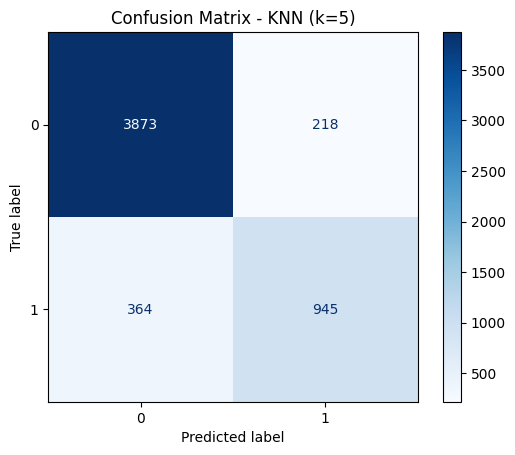

In [41]:
# Create binary target
y_class = (df['price'] >= 650000).astype(int)
print("Proportion of high-value houses (>=650K):", y_class.mean())

# Split data
X_train_cl, X_test_cl, y_train_cl, y_test_cl = train_test_split(X, y_class, test_size=0.25, random_state=42)

# Scale features
scaler_cl = StandardScaler()
X_train_cl_scaled = scaler_cl.fit_transform(X_train_cl)
X_test_cl_scaled = scaler_cl.transform(X_test_cl)

# Classification models
models_cl = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree (depth=3)': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest (n=100, depth=3)': RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

def evaluate_classification(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"{name:22} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
    return acc, prec, rec, f1

print("\n=== Classification Results (High-value >= 650K) ===\n")
results_cl = []
for name, model in models_cl.items():
    model.fit(X_train_cl_scaled, y_train_cl)
    y_pred_cl = model.predict(X_test_cl_scaled)
    acc, prec, rec, f1 = evaluate_classification(name, y_test_cl, y_pred_cl)
    results_cl.append((name, acc, prec, rec, f1))

# Best classifier
best_cl = max(results_cl, key=lambda x: x[4])
print("\n" + "="*70)
print(f" BEST CLASSIFIER: {best_cl[0]} (F1 = {best_cl[4]:.4f})")
print("="*70)

# Feature importance from Random Forest (for interpretability)
rf_cl = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_cl.fit(X_train_cl_scaled, y_train_cl)
importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_cl.feature_importances_})
print("\n Top 10 features driving high-value houses (>=650K):")
print(importances.sort_values('Importance', ascending=False).head(10))

# Confusion matrix for best classifier
best_model_cl = models_cl[best_cl[0]]
best_model_cl.fit(X_train_cl_scaled, y_train_cl)
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_model_cl, X_test_cl_scaled, y_test_cl, cmap='Blues')
plt.title(f'Confusion Matrix - {best_cl[0]}')
plt.show()